# DX 601 Final Project

## Introduction

In this project, you will practice all the skills that you have learned throughout this module.
You will pick a data set to analyze from a list provided, and then perform a variety of analysis.
Most of the problems and questions are open ended compared to your previous homeworks, and you will be asked to explain your choices.
Most of them will have a particular type of solution implied, but it is up to you to figure out the details based on what you have learned in this module.

## Instructions

Each problem asks you to perform some analysis of the data, and usually answer some questions about the results.
Make sure that your question answers are well supported by your analysis and explanations; simply stating an answer without support will earn minimal points.

Notebook cells for code and text have been added for your convenience, but feel free to add additional cells.

## Example Code

You may find it helpful to refer to this GitHub repository of Jupyter notebooks for example code.

* https://github.com/bu-cds-omds/dx500-examples
* https://github.com/bu-cds-omds/dx601-examples
* https://github.com/bu-cds-omds/dx602-examples

Any calculations demonstrated in code examples or videos may be found in these notebooks, and you are allowed to copy this example code in your homework answers.

## Submission

This project will be entirely manually graded.
However, we may rerun some or all of your code to confirm that it works as described.

### Late Policy

The normal homework late policy for OMDS does not apply to this project.
Boston University requires final grades to be submitted within 72 hours of class instruction ending, so we cannot accommodate 5 days of late submissions.

However, we have delayed the due date of this project to be substantially later than necessary given its scope, and given you more days for submission with full credit than you would have had days for submission with partial credit under the homework late policy.
Finally, the deadlines for DX 601 and DX 602 were coordinated to be a week apart while giving ample time for both of their projects.

## Shared Imports

For this project, you are forbidden to use modules that were not loaded in this template.
While other modules are handy in practice, modules that trivialize these problems interfere with our assessment of your own knowledge and skills.

If you believe a module covered in the course material (not live sessions) is missing, please check with your learning facilitator.

In [38]:
import math
import sys

In [39]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats
import sklearn.linear_model

from sklearn.decomposition import PCA

## Problems

### Problem 1 (5 points)

Pick one of the following data sets to analyze in this project.
Load the data set, and show a random sample of 10 rows.

* [Iris data set](https://archive.ics.uci.edu/dataset/53/iris) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/iris))
* [Breast Cancer Wisconsin](https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic) ([PMLB copy](https://github.com/EpistasisLab/pmlb/tree/master/datasets/_deprecated_breast_cancer_wisconsin))
* [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) ([PMLB - white subset only](https://github.com/EpistasisLab/pmlb/tree/master/datasets/wine_quality_white))


The PMLB copies of the data are generally cleaner and recommended for this project, but the other links are provided to give you more context.
To load the data from the PMLB Github repository, navigate to the `.tsv.gz` file in GitHub and copy the link from the "Raw" button.

If the data set you choose has more than ten columns, you may limit later analysis that is requested per column to just the first ten columns.

In [40]:
# reads the tsv file and assigns it to a variable name, separating the columns by tab
wine_quality_white = pd.read_csv('wine_quality_white.tsv', sep='\t')

# loads the data set and shows a random sample of 10 rows
wine_quality_white.sample(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,target
4669,5.9,0.44,0.33,1.2,0.049,12.0,117.0,0.99134,3.46,0.44,11.5,5
4104,6.9,0.45,0.27,4.7,0.035,17.0,80.0,0.99058,3.12,0.36,12.5,7
360,6.4,0.24,0.32,14.9,0.047,54.0,162.0,0.99680,3.28,0.50,10.2,6
4627,6.1,0.19,0.37,2.6,0.041,24.0,99.0,0.99153,3.18,0.50,10.9,6
3841,6.6,0.21,0.50,8.7,0.036,41.0,191.0,0.99294,2.96,0.56,11.0,6
4683,6.5,0.33,0.32,1.0,0.041,39.0,120.0,0.99004,3.06,0.37,12.2,6
3354,5.9,0.20,0.28,12.8,0.038,29.0,132.0,0.99426,3.31,0.57,11.8,7
163,7.4,0.24,0.42,14.0,0.066,48.0,198.0,0.99790,2.89,0.42,8.9,6
1019,8.3,0.14,0.26,1.5,0.049,56.0,189.0,0.99460,3.21,0.62,9.5,6
1962,8.2,0.21,0.48,1.4,0.041,11.0,99.0,0.99580,3.17,0.57,9.9,5


For this project, I'll be analyzing the Wine Quality data set. The first 10 rows of the data are visible above.

### Problem 2 (10 points)

List all the columns in the data set, and describe each of them in your own words.
You may have to search to learn about the data set columns, but make sure that the descriptions are your own words.

In [41]:
wine_quality_white.columns

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'target'],
      dtype='object')

In the data set, there are 12 columns. They are the following: 
- fixed acidity: The acid that is in wine that gives the wine a tart and crisp taste.
- volatile acidity: The acid that smells sharp. Too much of this acid and the wine can smell like vinegar.
- citric acid: A citrus-like acid that adds freshness to the wine.
- residual sugar: This is the leftover sugar after the wine is fermented.
- chlorides: This is the salt levels of the wine.
- free sulfur dioxide: This protects the wine from spoiling.
- total sulfur dioxide: This is the total amount of all of the sulfur dioxide in the wine.
- density: How "heavy" the wine is compared to water.
- pH: How strong the wine's acidity is.
- sulphates: These help to perserve the wine.
- alcohol: The percentage of ethanol, affecting the wine's warmth, body, and flavor.
- target: The quality of the wine, a score of 1-10.

### Problem 3 (15 points)

Plot histograms of each column.
For each column, state the distribution covered in this module that you think best matches that column.

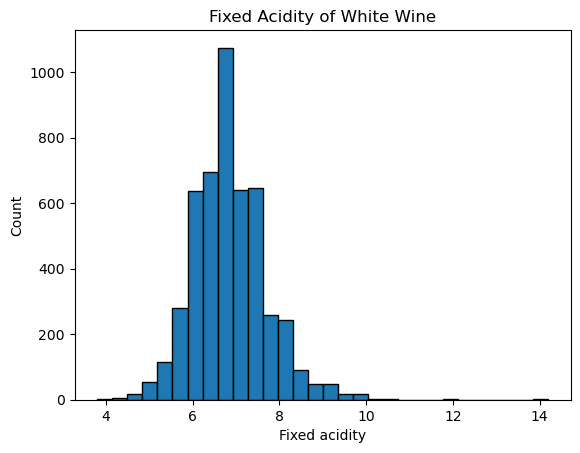

In [42]:
# fixed acidity histogram
plt.hist(wine_quality_white["fixed acidity"], edgecolor="black", bins=30)
plt.title("Fixed Acidity of White Wine")
plt.xlabel("Fixed acidity")
plt.ylabel("Count")
plt.show()


The fixed acidity histogram has an approximately normal distribution.

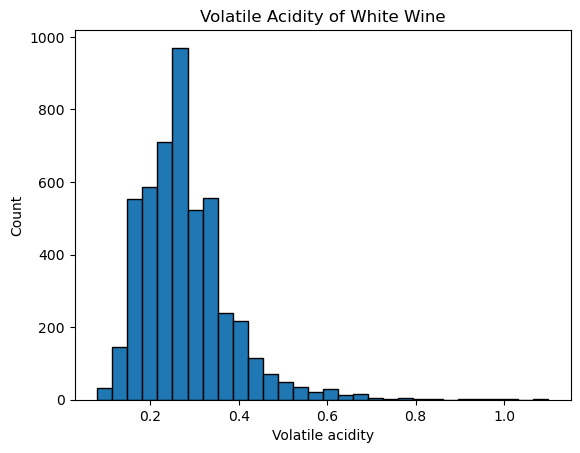

In [43]:
# volatile acidity histogram
plt.hist(wine_quality_white["volatile acidity"], edgecolor="black", bins=30)
plt.title("Volatile Acidity of White Wine")
plt.xlabel("Volatile acidity")
plt.ylabel("Count")
plt.show()

The volatile acidity histogram has a right-skewed distribution.

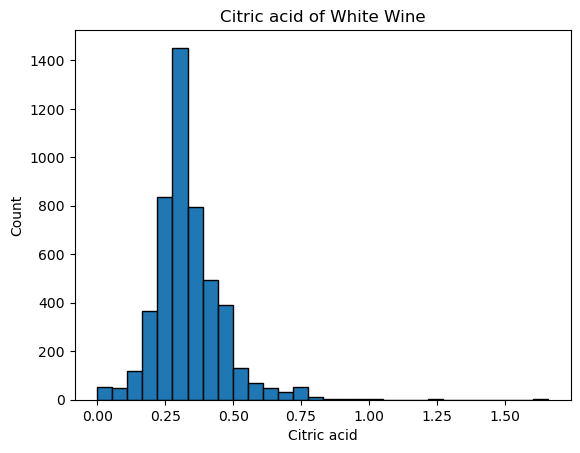

In [44]:
# citric acid histogram
plt.hist(wine_quality_white["citric acid"], edgecolor="black", bins=30)
plt.title("Citric acid of White Wine")
plt.xlabel("Citric acid")
plt.ylabel("Count")
plt.show()

The cirtic acid histogram has a right-skewed distribution.

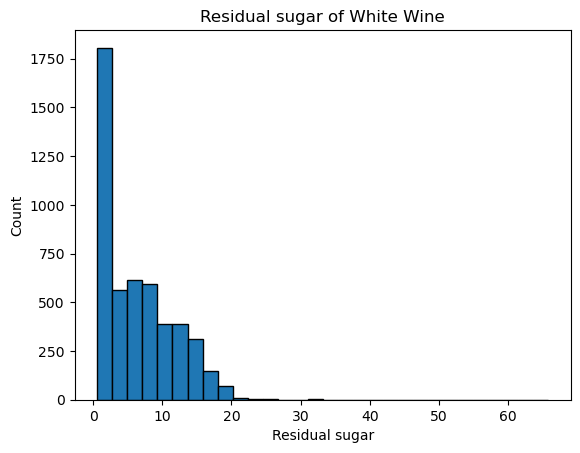

In [45]:
# residual sugar histogram
plt.hist(wine_quality_white["residual sugar"], edgecolor="black", bins=30)
plt.title("Residual sugar of White Wine")
plt.xlabel("Residual sugar")
plt.ylabel("Count")
plt.show()

The residual sugar histogram has a right-skewed distribution.

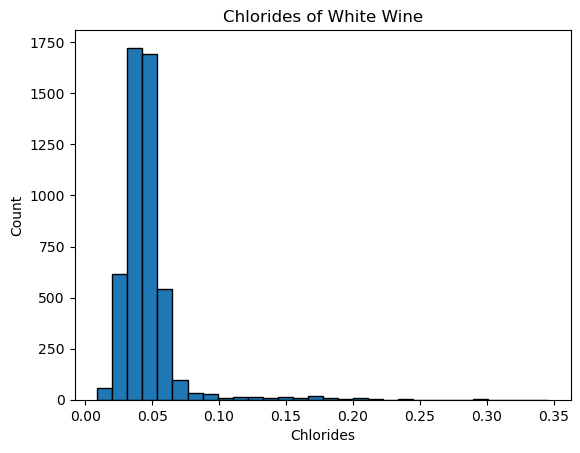

In [46]:
# chlorides histogram
plt.hist(wine_quality_white["chlorides"], edgecolor="black", bins=30)
plt.title("Chlorides of White Wine")
plt.xlabel("Chlorides")
plt.ylabel("Count")
plt.show()

The chlorides histogram has a right-skewed distribution.

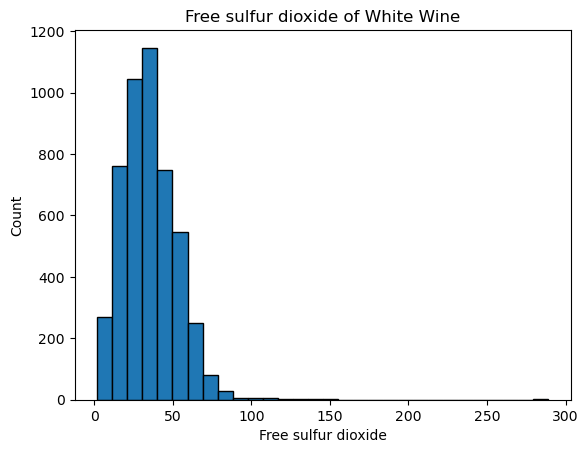

In [47]:
# free sulfur dioxide histogram
plt.hist(wine_quality_white["free sulfur dioxide"], edgecolor="black", bins=30)
plt.title("Free sulfur dioxide of White Wine")
plt.xlabel("Free sulfur dioxide")
plt.ylabel("Count")
plt.show()

The free sulfur dioxide histogram has a right-skewed distribution.

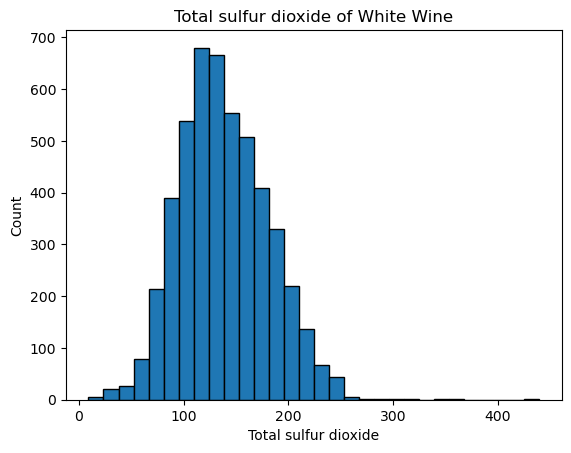

In [48]:
# total sulfur dioxide histogram
plt.hist(wine_quality_white["total sulfur dioxide"], edgecolor="black", bins=30)
plt.title("Total sulfur dioxide of White Wine")
plt.xlabel("Total sulfur dioxide")
plt.ylabel("Count")
plt.show()

The total sulfur dioxide histogram has a right-skewed distribution.

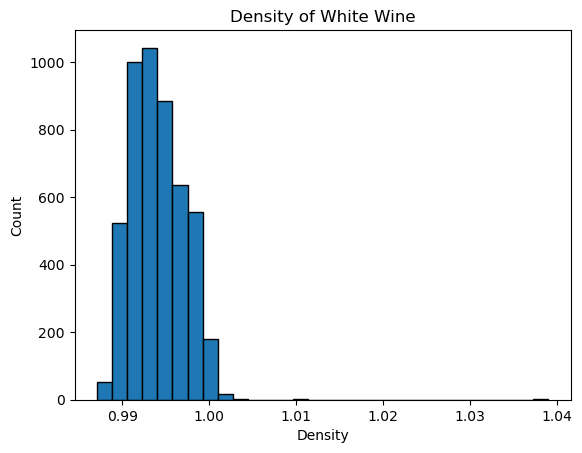

In [49]:
# density histogram
plt.hist(wine_quality_white["density"], edgecolor="black", bins=30)
plt.title("Density of White Wine")
plt.xlabel("Density")
plt.ylabel("Count")
plt.show()

The density histogram has a right-skewed distribution.

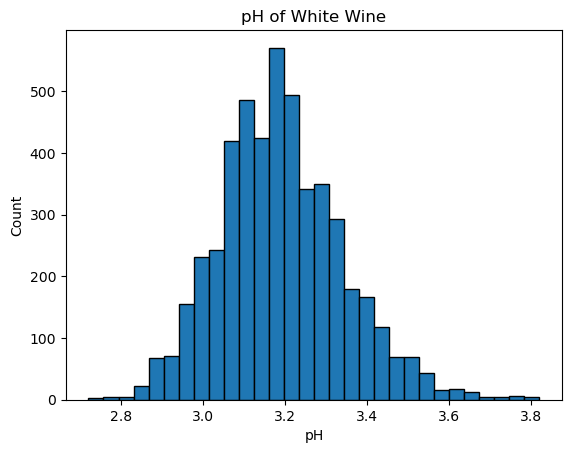

In [50]:
# pH histogram
plt.hist(wine_quality_white["pH"], edgecolor="black", bins=30)
plt.title("pH of White Wine")
plt.xlabel("pH")
plt.ylabel("Count")
plt.show()

The pH histogram has an approximately normal distribution.

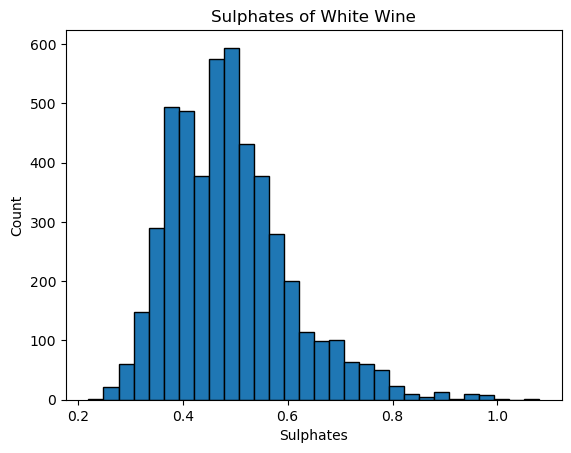

In [51]:
# sulphates histogram
plt.hist(wine_quality_white["sulphates"], edgecolor="black", bins=30)
plt.title("Sulphates of White Wine")
plt.xlabel("Sulphates")
plt.ylabel("Count")
plt.show()

The sulphates histogram has a right-skewed distribution.

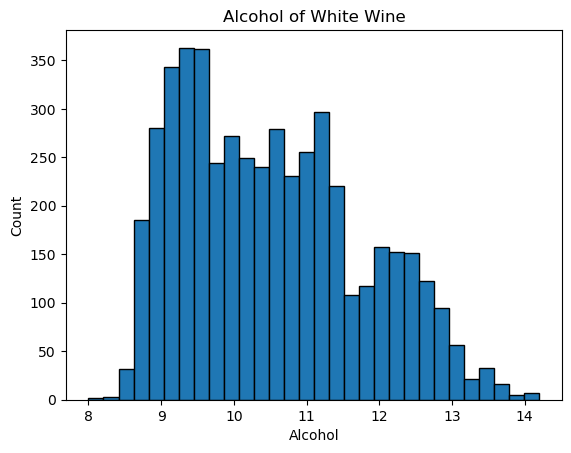

In [52]:
# alcohol histogram
plt.hist(wine_quality_white["alcohol"], edgecolor="black", bins=30)
plt.title("Alcohol of White Wine")
plt.xlabel("Alcohol")
plt.ylabel("Count")
plt.show()

The alcohol histogram has a right-skewed distribution.

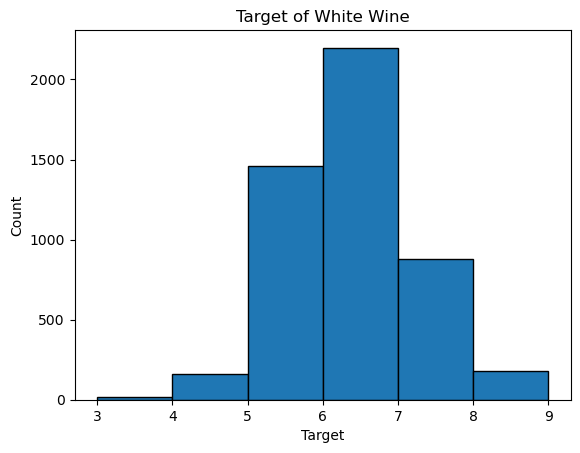

In [53]:
# target histogram
plt.hist(wine_quality_white["target"], edgecolor="black", bins=6)
plt.title("Target of White Wine")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

The target histogram has an approximately normal distribution, but also has a slight left-skewed distribution.

### Problem 4 (20 points)

Plot each pair of an input column and the output column.
Classify each pair of input column and the output column as being independent or not.
Describe in words why you think that was the case.

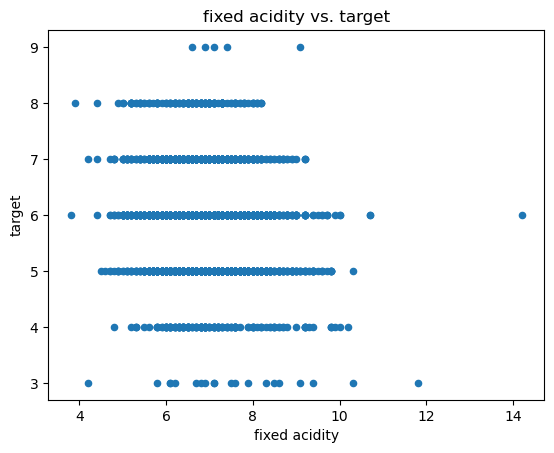

In [54]:
# YOUR CODE HERE
wine_quality_white.plot.scatter ("fixed acidity", "target")
plt.title("fixed acidity vs. target")
plt.show()

Target vs. fixed acidity is independent. There is no upward or downward trend. As the fixed acidity increases there is no pattern, the target doesn't increase or decrease.

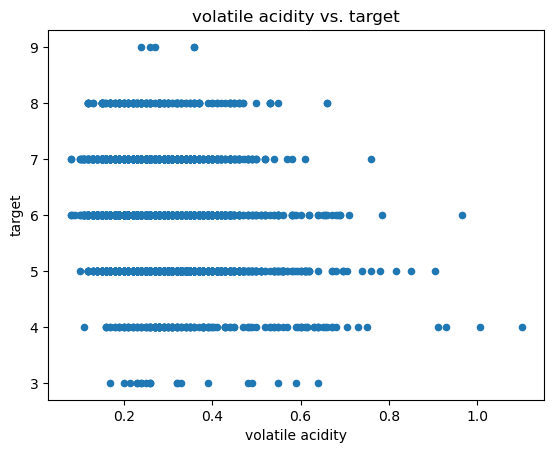

In [55]:
wine_quality_white.plot.scatter("volatile acidity", "target")
plt.title("volatile acidity vs. target")
plt.show()

Target vs. volatile acidity is independent of one another. There is no upward or downward trend. As the volatile acidity increases there is no pattern, the target doesn't increase or decrease.

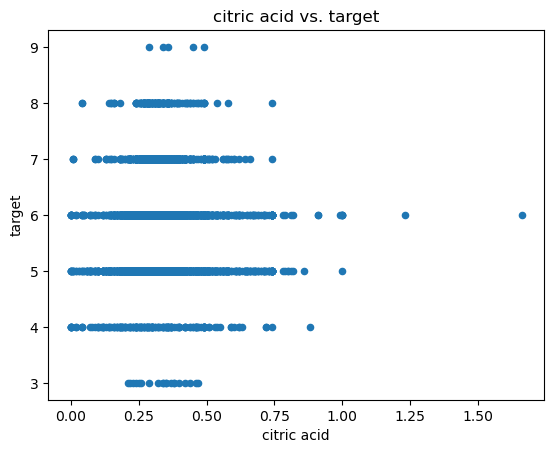

In [56]:
wine_quality_white.plot.scatter("citric acid", "target")
plt.title("citric acid vs. target")
plt.show()

Target vs. citric acid is mostly independent of one another. There is a slight dependency after the 6 target where the citric acid increases.

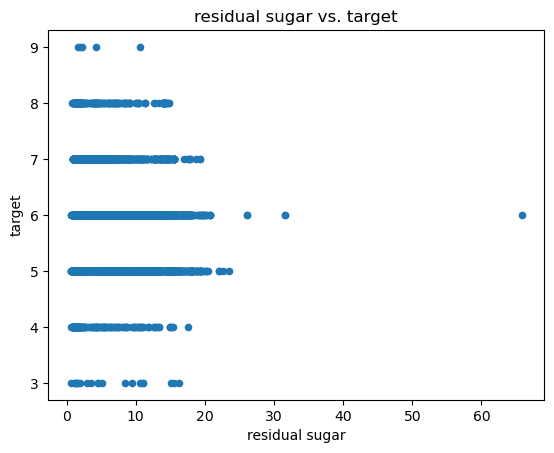

In [57]:
wine_quality_white.plot.scatter("residual sugar", "target")
plt.title("residual sugar vs. target")
plt.show()

Target vs. residual sugar are independent of one another. There is no upward or downward trend, and no pattern.

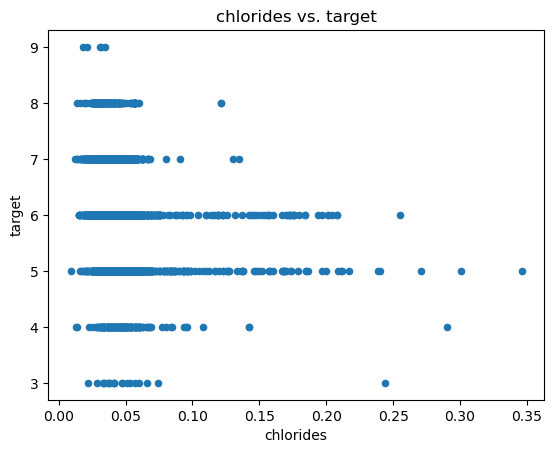

In [58]:
wine_quality_white.plot.scatter("chlorides", "target")
plt.title("chlorides vs. target")
plt.show()

Target vs. chloride doesn't have a strong relationship to one another, and has a slight pattern. When chloride increases, more wines are rated as a 5 or 6. But, it can be shown that wines with a higher target have lower chloride levels. It's a weak relationship and can't be called fully independent.

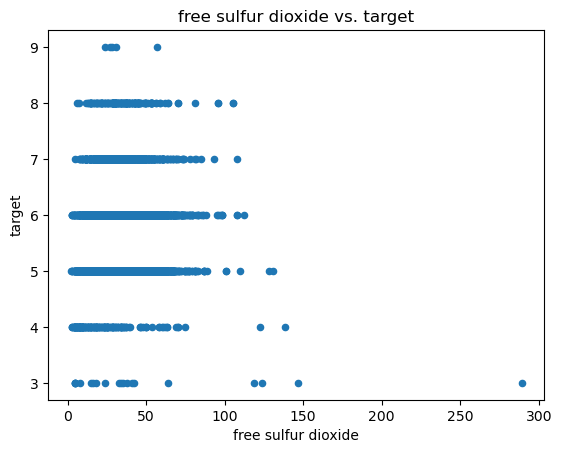

In [59]:
wine_quality_white.plot.scatter("free sulfur dioxide", "target")
plt.title("free sulfur dioxide vs. target")
plt.show()

Target vs. free sulfur dioxide are independent of one another. There is no upward or downward trend and there is no pattern.

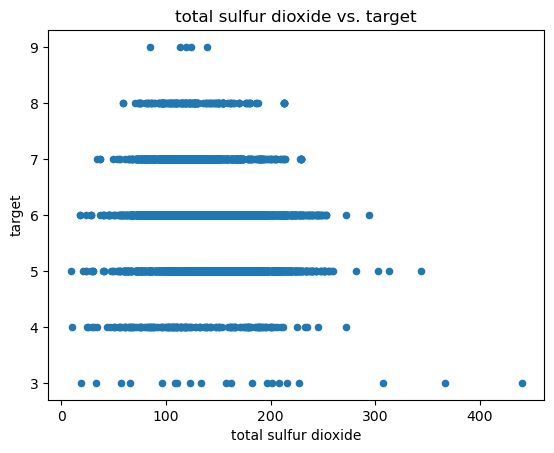

In [60]:
wine_quality_white.plot.scatter("total sulfur dioxide", "target")
plt.title("total sulfur dioxide vs. target")
plt.show()

This is a weak dependent-negative relationship. The target of the sulfter dioxide hits a peak and then as the higher the target, the lower the total sulfur dioxide. There is also a 'sweet spot' for the total sulfur. The higher rated wines have a total sulfur dioxide between 100 and 200.

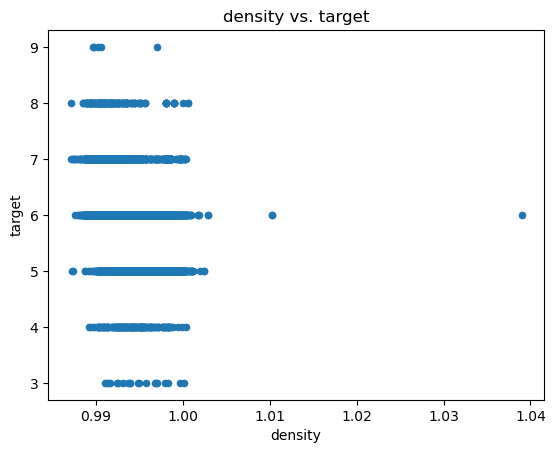

In [61]:
wine_quality_white.plot.scatter("density", "target")
plt.title("density vs. target")
plt.show()

The target and the density are independent of one another. There is no upward or downward trend. There is also no pattern.

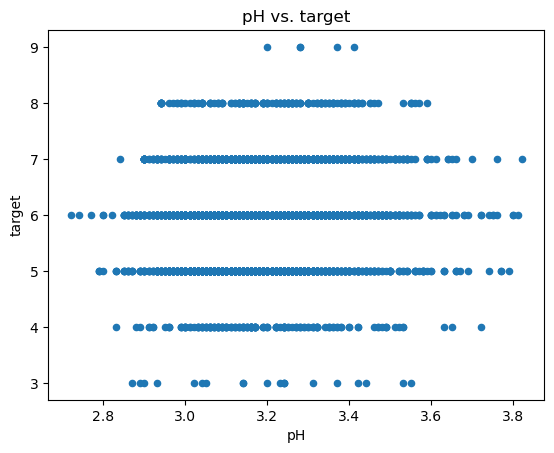

In [62]:
wine_quality_white.plot.scatter("pH", "target")
plt.title("pH vs. target")
plt.show()

The target vs. pH is mostly independent and has a pattern. as the target increases, the pH spreads, with a variety of pH values at the lower and upper end.

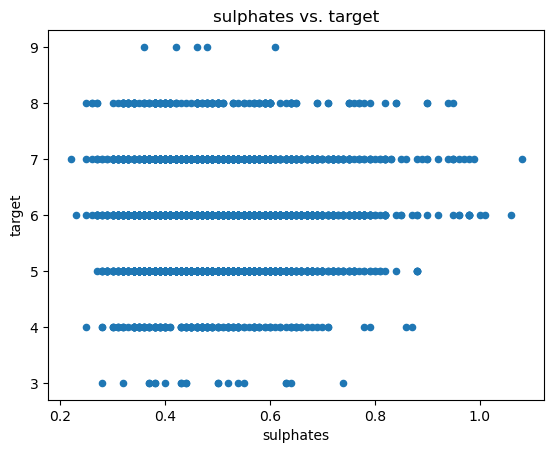

In [63]:
wine_quality_white.plot.scatter("sulphates", "target")
plt.title("sulphates vs. target")
plt.show()

Target and sulphates have a weak positive relationship, that is not fully independent. As target increases, the sulphate values begin to shift higher, specifically around target 6 through 8. 

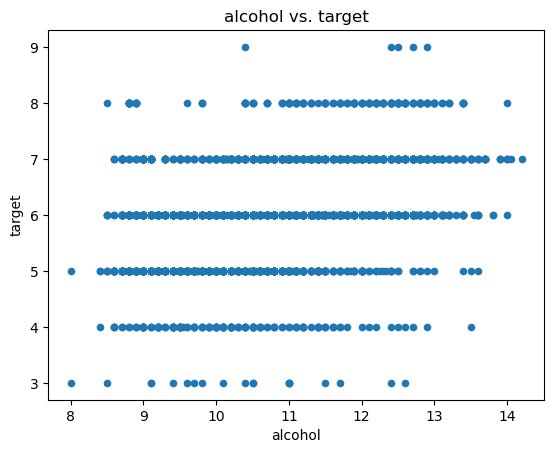

In [64]:
wine_quality_white.plot.scatter("alcohol", "target")
plt.title("alcohol vs. target")
plt.show()

There is a dependency between alcohol and the target. When the alcohol increases, the target increases for more wines. This has a slight upward trend and is a positive relationship.

### Problem 5 (20 points)

Build an ordinary least squares regression for the target using all the input columns.
Report the mean squared error of the model over the whole data set.
Plot the actual values vs the predicted outputs to compare them. 

The mean squared error of the actual target vs. the predicted target is 0.5631540629886557


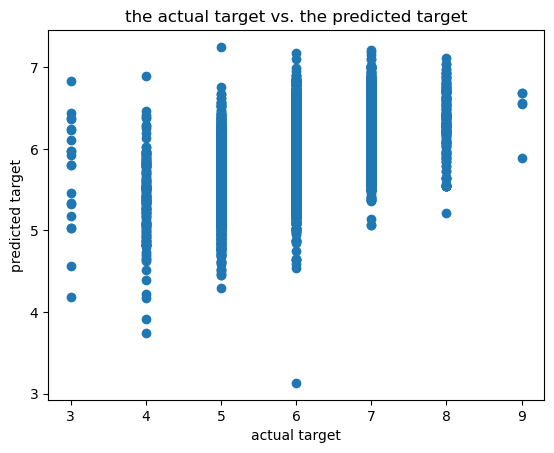

In [65]:
# importing Linear Regression
from sklearn.linear_model import LinearRegression

# creating the model
model = LinearRegression()

# drop the target column and keep the input columns for all rows of x
x = wine_quality_white.drop(columns="target")

# the target column
y = wine_quality_white["target"]

# fit the model using rows of x and y
model.fit(x, y)

# the model predicts a target value for each row in the x
predicted = model.predict(x)

# square the error of the actual - the predicted of each row
squared_error = (y - predicted) ** 2

# get the mean squared error
mean_squared_error = squared_error.mean()

print("The mean squared error of the actual target vs. the predicted target is", mean_squared_error)

# plotting the actual target vs. the predicted target
plt.scatter(y, predicted)
plt.xlabel("actual target")
plt.ylabel("predicted target")
plt.title('the actual target vs. the predicted target')
plt.show()

This scatter plot is comparing the actual target values to the predicted target values from the linear regression model. The plot shows an upward trend. As the actual target increases, the predicted target also increases. This means that the model is showing the relationship between the wine quality and the input variables. The points are still significantly spread out, so the predictions of course are not perfect. It appears to be predicting most of the values to be in the middle ranges, between 5 and 7. It isn't capturing anything very low or very high.

### Problem 6 (20 points)

Which input column gives the best linear model of the target on its own?
How does that model compare to the model in problem 5?


The MSE for fixed acidity is 0.7740643377514039


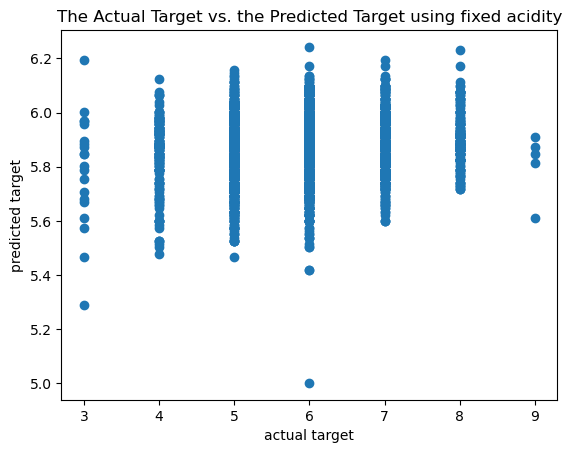

The MSE for volatile acidity is 0.7544611777913113


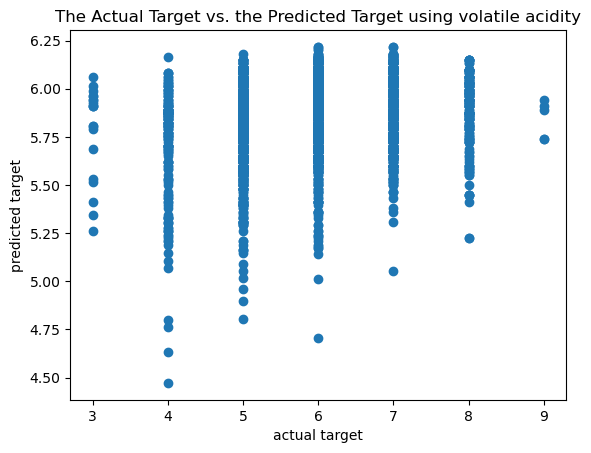

The MSE for citric acid is 0.7841290419696331


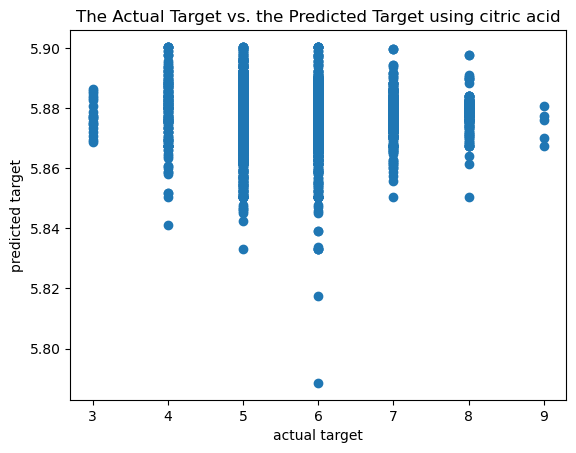

The MSE for residual sugar is 0.7767290354362435


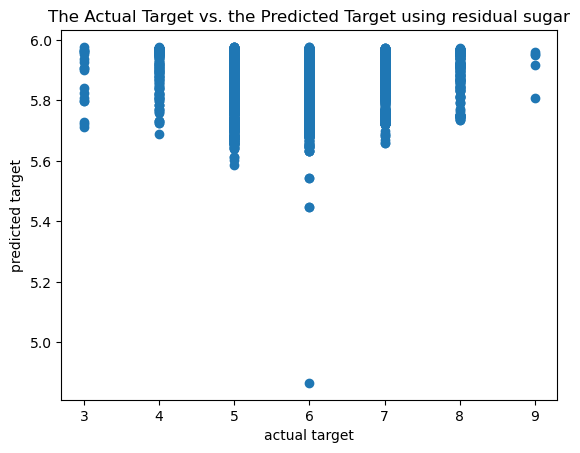

The MSE for chlorides is 0.7496341230508563


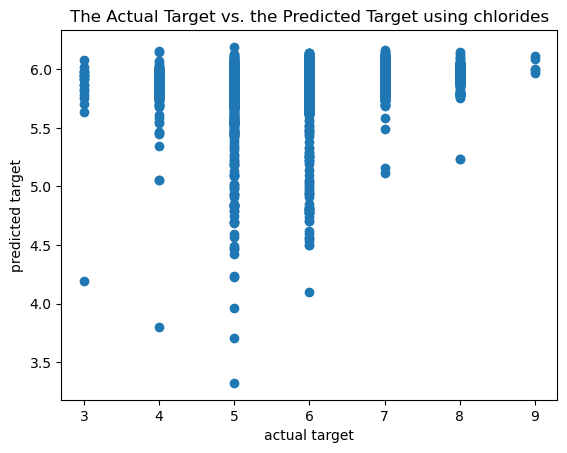

The MSE for free sulfur dioxide is 0.7841433561228635


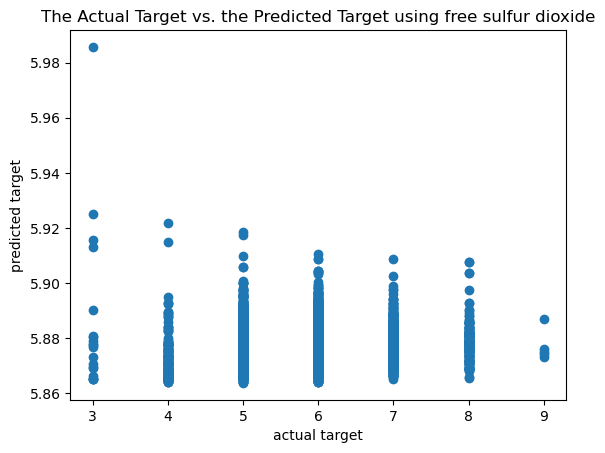

The MSE for total sulfur dioxide is 0.7602516302012772


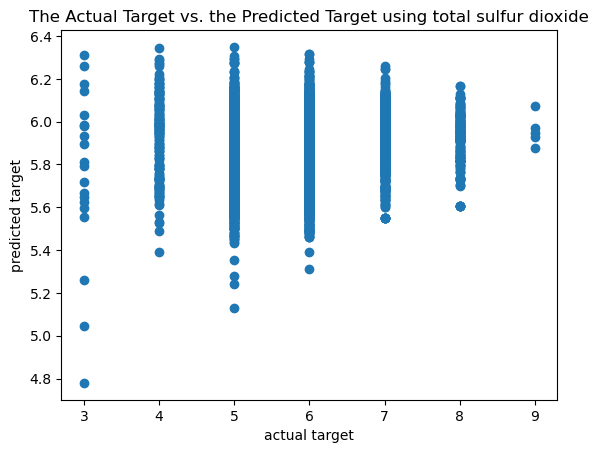

The MSE for density is 0.7102265148403777


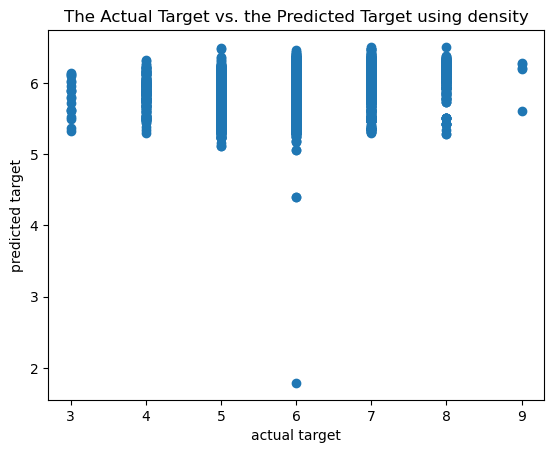

The MSE for pH is 0.776443165059832


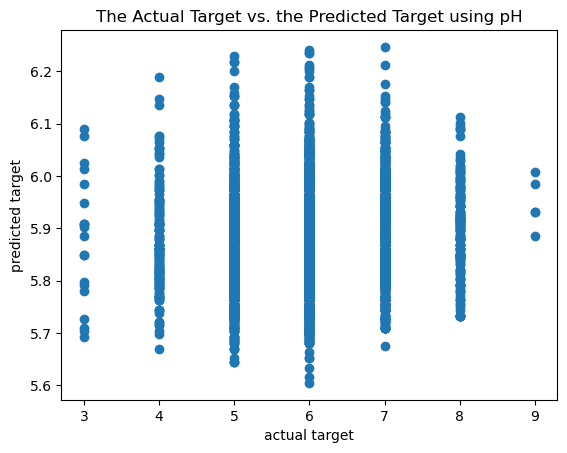

The MSE for sulphates is 0.7819360335229564


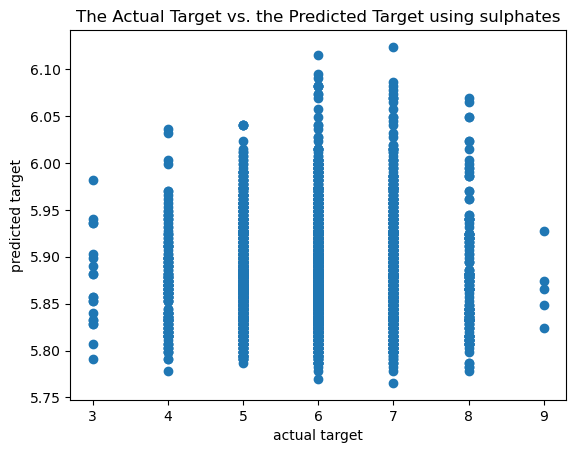

The MSE for alcohol is 0.6354137863260801


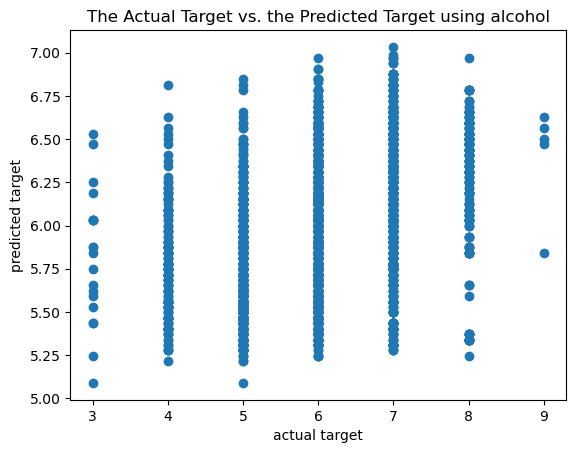

In [66]:
# making a loop to go through each column and get the MSE. Otherwise, would have to write this out for each column

def best_linear_model():
  ''' creating a function that goes through each column's values, fits it into the model with the target, and gets the MSE'''

  # for each column in the data set wine quality white  
  for col in wine_quality_white.columns:

    # when you get to the 'target' column, skip it and continue to the others
    if col == 'target' : continue
    
    # get the values of the column and reshape them
    x = wine_quality_white[col].values.reshape(-1, 1)
    
    # the target column
    y = wine_quality_white["target"]

    # fit the model using rows of x and y
    model.fit(x, y)

    # the model predicts a target value for each row in x
    predicted = model.predict(x)

    # square the error of the actual - the predicted of each row
    squared_error = (y - predicted) ** 2

    # get the mean of the error
    mean_squared_error = squared_error.mean()

    # print the mean squared error for each column against the actual target
    print("The MSE for", col, "is",  mean_squared_error)

    # plot each of the models
    plt.scatter(y, predicted)
    plt.title(f"The Actual Target vs. the Predicted Target using {col}")
    plt.xlabel("actual target")
    plt.ylabel("predicted target")
    plt.show()

best_linear_model()

Of the pairs for each input, alcohol is the best model with the lowest MSE of 0.6354137863260801. But, the original model is the best, using with mean squared error of the actual target vs. the predicted target, which is 0.5631540629886557.


### Problem 7 (20 points)

Pick and plot a pair of input columns with a visible dependency.
Identify a split of the values of one column illustrating the dependency and plot histograms of the other variable on both sides of the split.
That is, pick a threshold $t$ for one column $x$ and make two histograms, one where $x < t$ and one where $x \geq t$.

These histograms should look significantly different to make the dependency clear.
There should be enough data in both histograms so that these differences are unlikely to be noise.
Also make sure that the horizontal axis is the same in both histograms for clarity.

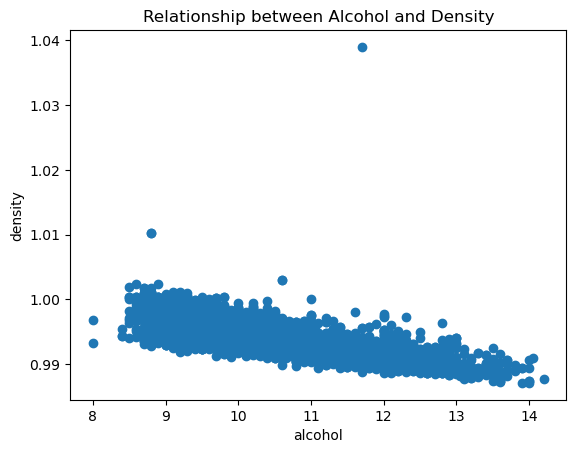

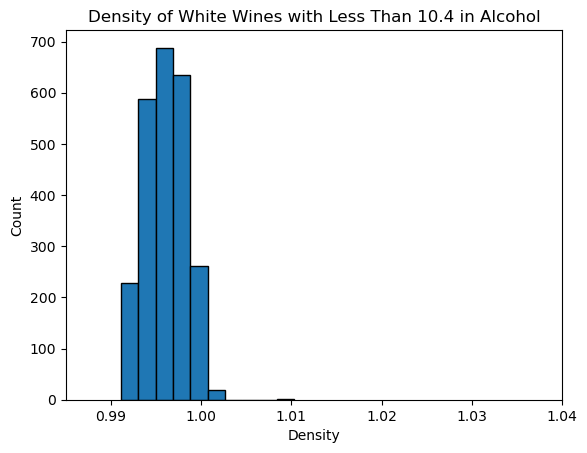

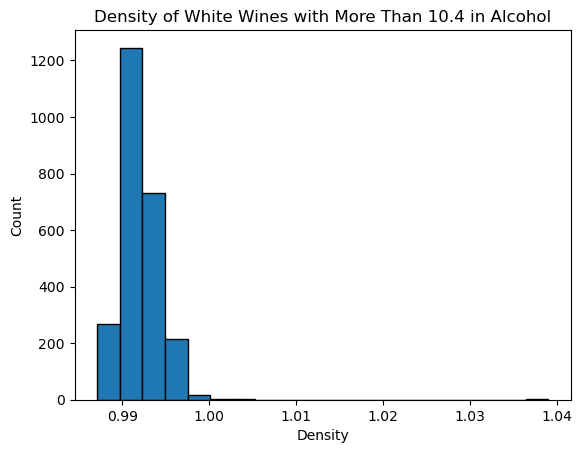

In [67]:
# threshold for alcohol, get the median, 10.4
t = wine_quality_white['alcohol'].median()

# gets all of the rows where the alcohol is less than the threshold, and displays the data set
less_than = wine_quality_white[wine_quality_white['alcohol'] < t]

# gets all of the rows where the alcohol is greater than the threshold, and displays the data set
greater_than = wine_quality_white[wine_quality_white['alcohol'] >= t]

# scatter plot to find dependencies across columns
plt.scatter(wine_quality_white['alcohol'], wine_quality_white['density'])
plt.title('Relationship between Alcohol and Density')
plt.xlabel('alcohol')
plt.ylabel('density')
plt.show()

# histogram for white wine densities 
plt.hist(less_than['density'], edgecolor='black')
plt.title('Density of White Wines with Less Than 10.4 in Alcohol')
plt.xlabel('Density')
plt.ylabel('Count')
plt.xlim(0.985, 1.04)
plt.show()

plt.hist(greater_than['density'], edgecolor='black', bins=20)
plt.title('Density of White Wines with More Than 10.4 in Alcohol')
plt.xlabel('Density')
plt.ylabel('Count')
plt.show()

Plotting a scatterplot first, you can sere that as the alcohol increases, the density decreases. This shows a negative relationship. Looking at the histograms above, the first represents the density of wines under the 10.4 threshold of alcohol. The second displays the same variables but above the 10.4 threshold. 

From the first histogram, you can see that the densities of the wines below the 10.4 alcohol threshold have higher densities than the second histogram. In the second histogram, there are lower densities for wines with alcohol value above the 10.4 threshold.

### Problem 8 (40 points)

Perform principal components analysis of the input columns.
Compute how much of the data variation is explained by the first half of the principal components.
Build a linear regression using coordinates computed from the first half of the principal components.
Compare the mean squared error of this model to the previous model.
Plot actual targets vs predictions again. 

This problem depends on material from week 13.

In [68]:
# chooses only the input columns, which excludes 'target'
wine_pca_columns = [c for c in wine_quality_white.columns if wine_quality_white[c].dtype=='float64']

x = wine_quality_white[wine_pca_columns]
y = wine_quality_white['target']

# fit the PCA on the input columns
wine_pca = PCA()
wine_pca.fit(x)

# put the principal components into a DataFrame
wine_quality_components = pd.DataFrame(wine_pca.components_, columns=wine_pca_columns)

# Principal components
print('The Principal Components')
print(wine_quality_components)

#the explained variance for each column
variance_wine_components = wine_pca.explained_variance_
print()
print('The explained variance')
print(variance_wine_components)


The Principal Components
    fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0        0.001544          0.000169     0.000339        0.047328   0.000098   
1       -0.009163         -0.001545     0.000140        0.014943  -0.000072   
2        0.012900          0.000929     0.001258        0.995192   0.000078   
3       -0.147658          0.015452    -0.005005        0.084200  -0.006573   
4        0.984965         -0.003978     0.041692       -0.000808  -0.001498   
5        0.073410         -0.106675    -0.016610        0.006031  -0.014278   
6       -0.048670         -0.324715     0.861603       -0.000154   0.012931   
7       -0.004963          0.162243    -0.352320       -0.000141   0.001499   
8       -0.001012          0.925158     0.361918       -0.001710   0.030959   
9        0.002217         -0.026135    -0.022043        0.000611   0.999300   
10      -0.000771         -0.000633    -0.000340       -0.000372  -0.004696   

    free sulfur dioxide  t

In [69]:
# looking at how much data variation is explained by first half of principal components
num_wine_components = len(wine_pca_columns) // 2

# first half get only the columns above and then add them
first_half = variance_wine_components[:num_wine_components].sum()

# total
total_variance = variance_wine_components.sum()
variation_explained = first_half / total_variance
print()
print(f'{variation_explained} of the data variation is explained by the first half of the principal components.')

# computing coordinates by transforming
pca_coordinates_transform = wine_pca.transform(x)

# pca coordinates into a DataFrame
wine_pca_coordinates = pd.DataFrame(pca_coordinates_transform)
print()
print('PCA Coordinates')
print(wine_pca_coordinates.head(10))

# first half of the coordinates
wine_pca_coord_half = wine_pca_coordinates.iloc[:, :num_wine_components]
print()
print('First half PCA Coordinates')
print(wine_pca_coord_half.head(10))



0.9999748951314685 of the data variation is explained by the first half of the principal components.

PCA Coordinates
          0          1          2         3         4         5         6   \
0  33.732754   1.238285  12.775292 -0.234922 -0.088245 -0.100476  0.014614   
1 -11.925800 -18.957519  -3.857834 -1.249988 -0.858999  0.031639  0.025850   
2 -41.224671   5.739874   2.466032 -0.953471  1.192391  0.171030 -0.030876   
3  49.087353  -1.213107  -0.193184 -0.048469  0.254910 -0.011453 -0.058192   
4  49.087353  -1.213107  -0.193184 -0.048469  0.254910 -0.011453 -0.058192   
5 -41.224671   5.739874   2.466032 -0.953471  1.192391  0.171030 -0.030876   
6  -3.626238  -4.491289   0.913870 -0.742538 -0.826385 -0.056703 -0.136101   
7  33.732754   1.238285  12.775292 -0.234922 -0.088245 -0.100476  0.014614   
8 -11.925800 -18.957519  -3.857834 -1.249988 -0.858999  0.031639  0.025850   
9 -11.171800  -4.671865  -4.298669 -0.170894  1.263824  0.083021  0.031462   

         7         8  

In [70]:
# linear regression
x_regression = wine_pca_coord_half
y_regression = y

wine_pca_model = LinearRegression()
wine_pca_model.fit(x_regression, y_regression)

wine_pca_prediction = wine_pca_model.predict(x_regression)

# compute MSE
wine_pca_errors = y_regression - wine_pca_prediction
pca_squared_errors = wine_pca_errors ** 2
wine_pca_mse = pca_squared_errors.mean()
print('MSE of PCA:', wine_pca_mse)

MSE of PCA: 0.6121738755415853


Of the pairs for each input, the MSE of the PCA is with a value of 0.6121738755415853. This is better than the MSE of alcohol against the predicted target. But, the original model is the best, using with mean squared error of the actual target vs. the predicted target, which is 0.5631540629886557.

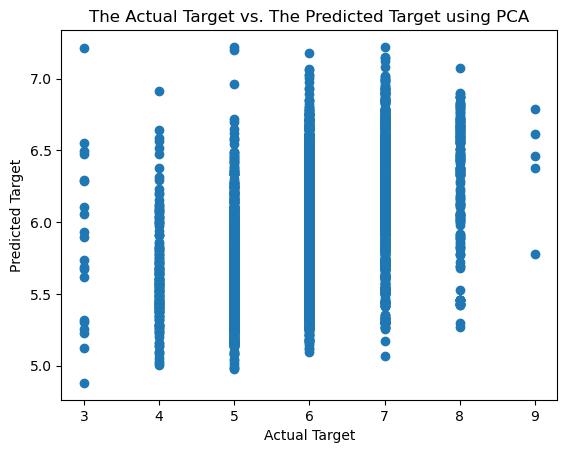

In [71]:
# plotting the actual target vs the predictions
plt.scatter(y_regression, wine_pca_prediction)
plt.title("The Actual Target vs. The Predicted Target using PCA")
plt.xlabel("Actual Target")
plt.ylabel("Predicted Target")
plt.show()

### Problem 9 (20 points)

What pair of input columns has the highest correlation?
How is that correlation reflected in the principal components?

In [72]:
# input columns only
wine_columns = wine_quality_white.drop(columns='target')

# compute correlations
wine_correlation = wine_columns.corr()

# gets absolute value 
absolute_wine_correlation = wine_correlation.abs()

# remotes the diagonal 1's
np.fill_diagonal(absolute_wine_correlation.values, 0)

# Correlation Matrix
print(absolute_wine_correlation)

# highest correlations
# ph and fixed acidity = .425858
# citric acid and volatile acidity - .149472
# fixed acidity and citric acid - .289181
# density and residual sugar - .838966
# alcohol and chlorides - 0.360189
# total sulfur dioxide and free sulfur dioxide - .615501
# free sulfur dioxide and total sulfur dioxide - .615501
# ph and sulphates - .155951
# density and alcohol - .780138


                      fixed acidity  volatile acidity  citric acid  \
fixed acidity              0.000000          0.022697     0.289181   
volatile acidity           0.022697          0.000000     0.149472   
citric acid                0.289181          0.149472     0.000000   
residual sugar             0.089021          0.064286     0.094212   
chlorides                  0.023086          0.070512     0.114364   
free sulfur dioxide        0.049396          0.097012     0.094077   
total sulfur dioxide       0.091070          0.089261     0.121131   
density                    0.265331          0.027114     0.149503   
pH                         0.425858          0.031915     0.163748   
sulphates                  0.017143          0.035728     0.062331   
alcohol                    0.120881          0.067718     0.075729   

                      residual sugar  chlorides  free sulfur dioxide  \
fixed acidity               0.089021   0.023086             0.049396   
volatile acidit

The highest correlation is between density and residual sugar: 0.838966

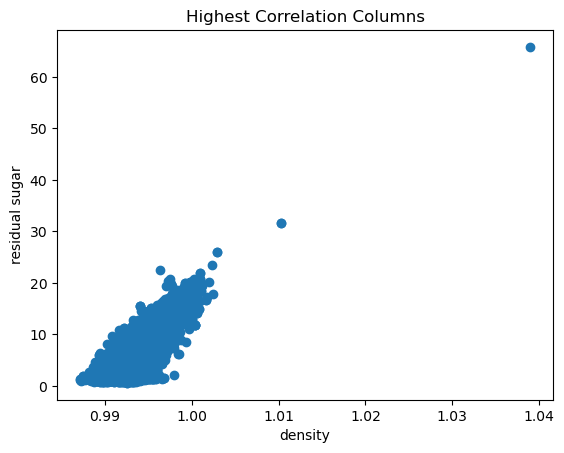

     density  residual sugar
0   0.000036        0.047328
1  -0.000018        0.014943
2   0.000447        0.995192
3  -0.001152        0.084200
4   0.000328       -0.000808
5   0.003634        0.006031
6   0.000084       -0.000154
7   0.000130       -0.000141
8   0.001263       -0.001710
9   0.004704        0.000611
10  0.999981       -0.000372


In [73]:
# plot columns against one another to show correlation
plt.scatter(wine_quality_white['density'], wine_quality_white['residual sugar'])
plt.title('Highest Correlation Columns')
plt.xlabel('density')
plt.ylabel('residual sugar')
plt.show()

# putting columns in the PCA
print(wine_quality_components[['density', 'residual sugar']])

With density and residual sugar with the highest correlation, the scatter plot above shows the positive relationship. Wines with higher density are likely to have higher residual sugar. When both are reflected in the PCA, residual sugar has its largest weight in row 2, principal component 3. Density has it's largest weight in principal component 11, row 10. The correlation isn't reflected in the PCA. If it was, they would both be weighted heavily in the same component.

### Problem 10 (30 points)

Identify an outlier row in the data set.
You may use any criteria discussed in this module, and you must explain the criteria and how it led to picking this row.
Give a visualization showing how much this row sticks out compared to the other data based on your criteria.

Z-scores of all columns in the outlier row
      fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
2781       1.120095          6.813453     2.196405       11.712916   1.292003   

      free sulfur dioxide  total sulfur dioxide    density        pH  \
2781             1.605684              0.509184  15.029763  1.335977   

      sulphates   alcohol  
2781   1.753793  0.963524  


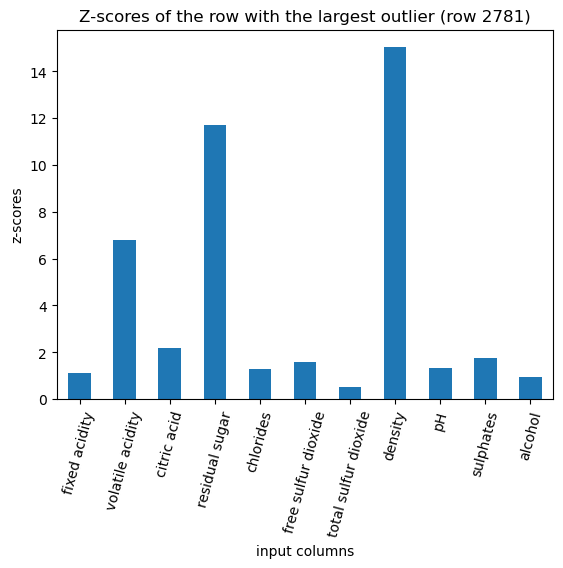

In [74]:
# input columns only, dropping the target column
wine_columns = wine_quality_white.drop(columns='target')

# getting the z scores of each row and getting absolute values
z_scores = ((wine_columns - wine_columns.mean()) / wine_columns.std()).abs()

# find the largest z scores to find the outliers in each row, so need to use axis
max_z_scores = z_scores.max(axis=1)

# finds the exact row that has the highest z score, which is outlier row
max_outlier_row = max_z_scores.idxmax() # row # 2781

# find which column caused row to have highest z score
max_outlier_column = z_scores.loc[max_outlier_row].idxmax() # density

print('Z-scores of all columns in the outlier row')
print(z_scores.loc[[max_outlier_row]]) # largest are residual sugar, volatile acidity, and density

# max_z_scores[2781]
# z-score is 15.029 for density
# # max_outlier_column
# # max_outlier_row
# max_z_scores

#the visualization as a bar chart
z_scores.loc[max_outlier_row].plot(kind='bar')
plt.title('Z-scores of the row with the largest outlier (row 2781)')
plt.xticks(rotation=75)
plt.xlabel('input columns')
plt.ylabel('z-scores')
plt.show()

I used z-score to identify the outlier row because it was the simplest way for myself. Z-score shows how far a value is from the stand deviation units. I also did absolute z-scores to make sure it included even the negative z-scores because that would identify the outliers as well on the other side of the distribution. I found the outlier row by calculating the input of each column, then found the largest z-score in each row.

The row 2781 had the largest outlier. The largest outlier was under the density column with a value of 15.029763. The bar chart above shows the scores for all of the columns in that row. Residual sugar and volatile acidity also had high z-scores.

### Generative AI Usage

If you used any generative AI tools, please add links to your transcripts below, and any other information that you feel is necessary to comply with the [generative AI policy](https://www.bu.edu/cds-faculty/culture-community/gaia-policy/).
If you did not use any generative AI tools, simply write NONE below.

<h3>Problem 8</h3>
TerrierGPT, Claude 4.6 Sonnet https://terriergpt.bu.edu/share/x8kwpPN5hYpEtvSEI-SwW<br>
wanted syntax to find the PCA coordinates. The output was too complicated and didn't understand it well. So went back to class examples and module notes and scanned it to find the simpliest way to calculate.

<h3>Problem 10</h3>
TerrierGPT, OpenAI GPT-5 mini, https://terriergpt.bu.edu/share/YzVEx21jytwrzdFMIbKZL<br>
Wanted more clarification on z-scores and wanted syntax for libraries using minimal code.
